In [113]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
# os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

In [114]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [115]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_LMP_Forecasts", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load_Forecasts", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN_DAM_Forecasts", "FR_ren_processed.csv")
def split_data(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
    train = df[(df['date'] >= '2019-10-01') & (df['date'] <= '2023-09-30')].reset_index(drop=True)
    dev   = df[(df['date'] >= '2023-10-01') & (df['date'] <= '2024-09-30')].reset_index(drop=True)
    test  = df[(df['date'] >= '2024-10-01') & (df['date'] <= '2025-09-30')].reset_index(drop=True)
    return train, dev, test

def create_sliding_window(data_df,string, window_days=7, forecast_horizon=24):
    """
    Create sliding windows for day-ahead electricity price forecasting.
    Each input corresponds to `window_days` past days (window_days * 24 hours),
    and each output corresponds to the next day's 24 hourly prices.

    Parameters
    ----------
    data_df : pd.DataFrame
        Must contain a 'EUR/MWh' column with hourly prices.
    window_days : int
        Number of past days (each 24 hours) used as input.
    forecast_horizon : int
        Typically 24 (hours in the day to forecast).
    string :  the name of the column of interest
    Returns
    -------
    X : np.ndarray of shape (n_samples, window_days*24)
    y : np.ndarray of shape (n_samples, forecast_horizon)
    """
    series = data_df[string].values
    hours_per_day = 24
    window_size = window_days * hours_per_day

    X, y, y_day_before, y_week_before = [], [], [], []

    for i in range(0, len(series) - window_size - forecast_horizon + 1):
        # Input window: past `window_size` hours
        X_window = series[i : i + window_size]
        # Target: next `forecast_horizon` hours
        y_target = series[i + window_size : i + window_size + forecast_horizon]

        # --- Naive baselines ---
        # previous day
        if i - hours_per_day >= 0:
            y_prev_day = series[i + window_size - hours_per_day : i + window_size - hours_per_day + forecast_horizon]
        else:
            y_prev_day = np.full(forecast_horizon, np.nan)

        # previous week
        if i - 7 * hours_per_day >= 0:
            y_prev_week = series[i + window_size - 7 * hours_per_day : i + window_size - 7 * hours_per_day + forecast_horizon]
        else:
            y_prev_week = np.full(forecast_horizon, np.nan)

        X.append(X_window)
        y.append(y_target)
        y_day_before.append(y_prev_day)
        y_week_before.append(y_prev_week)

    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32), np.asarray(y_day_before, dtype=np.float32), np.asarray(y_week_before, dtype=np.float32)

In [116]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data=pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'],how='inner')
all_data=pd.merge(all_data, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'],how='inner')
all_data


,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,MW,Wind Onshore,Solar
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00
...,...,...,...,...,...,...,...,...,...,...
52182,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72
52183,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89
52184,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00
52185,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00


In [117]:

#Normalization and splitting
train_df_FR, dev_df_FR, test_df_FR = split_data(all_data)

mean_FR = train_df_FR['EUR/MWh'].mean()
std_FR = train_df_FR['EUR/MWh'].std()
train_df_FR['EUR/MWh'] = (train_df_FR['EUR/MWh'] - mean_FR) / std_FR
dev_df_FR['EUR/MWh'] = (dev_df_FR['EUR/MWh'] - mean_FR) / std_FR
test_df_FR['EUR/MWh'] = (test_df_FR['EUR/MWh'] - mean_FR) / std_FR
mean_load_FR = train_df_FR['MW'].mean()
std_load_FR = train_df_FR['MW'].std()
train_df_FR['MW'] = (train_df_FR['MW'] - mean_load_FR) / std_load_FR
dev_df_FR['MW'] = (dev_df_FR['MW'] - mean_load_FR) / std_load_FR
test_df_FR['MW'] = (test_df_FR['MW'] - mean_load_FR) / std_load_FR
mean_solar_FR = train_df_FR['Solar'].mean()
std_solar_FR = train_df_FR['Solar'].std()
train_df_FR['Solar'] = (train_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
dev_df_FR['Solar'] = (dev_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
test_df_FR['Solar'] = (test_df_FR['Solar'] - mean_solar_FR) / std_solar_FR
mean_wind_FR = train_df_FR['Wind Onshore'].mean()
std_wind_FR = train_df_FR['Wind Onshore'].std()
train_df_FR['Wind Onshore'] = (train_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR
dev_df_FR['Wind Onshore'] = (dev_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR
test_df_FR['Wind Onshore'] = (test_df_FR['Wind Onshore'] - mean_wind_FR) / std_wind_FR

#Create a dictonary for storing means and standard deviations
normalization_params_FR = {
    'EUR/MWh': {'mean': mean_FR, 'std': std_FR},
    'MW': {'mean': mean_load_FR, 'std': std_load_FR},
    'Solar': {'mean': mean_solar_FR, 'std': std_solar_FR},
    'Wind Onshore': {'mean': mean_wind_FR, 'std': std_wind_FR}
}

In [118]:
#Create sliding windows

window_days = 7
forecast_horizon = 24
X_train_FR, y_train_FR, y_train_FR_1d, y_train_FR_7d = create_sliding_window(train_df_FR, string='EUR/MWh', window_days=7, forecast_horizon=24)
X_dev_FR,   y_dev_FR,   y_dev_FR_1d, y_dev_FR_7d = create_sliding_window(dev_df_FR, string='EUR/MWh', window_days=7, forecast_horizon=24)
X_test_FR,  y_test_FR,  y_test_FR_1d, y_test_FR_7d = create_sliding_window(test_df_FR, string='EUR/MWh', window_days=7, forecast_horizon=24)
X_load_train_FR, _, _, _ = create_sliding_window(train_df_FR, string='MW', window_days=7, forecast_horizon=24)
X_load_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR, string='MW', window_days=7, forecast_horizon=24)
X_load_test_FR,  _, _, _ = create_sliding_window(test_df_FR, string='MW', window_days=7, forecast_horizon=24)
X_solar_train_FR, _, _, _ = create_sliding_window(train_df_FR, string='Solar', window_days=7, forecast_horizon=24)
X_solar_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR, string='Solar', window_days=7, forecast_horizon=24)
X_solar_test_FR,  _, _, _ = create_sliding_window(test_df_FR, string='Solar', window_days=7, forecast_horizon=24)
X_wind_train_FR, _, _, _ = create_sliding_window(train_df_FR, string='Wind Onshore', window_days=7, forecast_horizon=24)
X_wind_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR, string='Wind Onshore', window_days=7, forecast_horizon=24)
X_wind_test_FR,  _, _, _ = create_sliding_window(test_df_FR, string='Wind Onshore', window_days=7, forecast_horizon=24)


In [119]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
train_df_FR_cyclic = add_cyclical_features(train_df_FR)
dev_df_FR_cyclic = add_cyclical_features(dev_df_FR)
test_df_FR_cyclic = add_cyclical_features(test_df_FR)
X_sin_hour_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7, forecast_horizon=24)
X_cos_hour_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7, forecast_horizon=24)
X_sin_hour_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7, forecast_horizon=24)
X_cos_hour_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7, forecast_horizon=24)
X_sin_hour_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['sin_hour']], string='sin_hour', window_days=7, forecast_horizon=24)
X_cos_hour_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['cos_hour']], string='cos_hour', window_days=7, forecast_horizon=24)
X_sin_day_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7, forecast_horizon=24)
X_cos_day_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7, forecast_horizon=24)
X_sin_day_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7, forecast_horizon=24)
X_cos_day_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7, forecast_horizon=24)
X_sin_day_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['sin_day']], string='sin_day', window_days=7, forecast_horizon=24)
X_cos_day_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['cos_day']], string='cos_day', window_days=7, forecast_horizon=24)
X_sin_month_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7, forecast_horizon=24)
X_cos_month_train_FR, _, _, _ = create_sliding_window(train_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7, forecast_horizon=24)
X_sin_month_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7, forecast_horizon=24)
X_cos_month_dev_FR,   _, _, _ = create_sliding_window(dev_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7, forecast_horizon=24)
X_sin_month_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['sin_month']], string='sin_month', window_days=7, forecast_horizon=24)
X_cos_month_test_FR,  _, _, _ = create_sliding_window(test_df_FR_cyclic[['cos_month']], string='cos_month', window_days=7, forecast_horizon=24)

In [120]:
print(X_train_FR.shape)
print(X_load_train_FR.shape)
print(X_solar_train_FR.shape)
print(X_wind_train_FR.shape)
print(X_sin_hour_train_FR.shape)
print(X_cos_hour_train_FR.shape)
print(X_sin_day_train_FR.shape)
print(X_cos_day_train_FR.shape)
print(X_sin_month_train_FR.shape)
print(X_cos_month_train_FR.shape)



(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)
(34458, 168)


In [121]:
#Concatenate corresponding datasets to have (m,168,8)
X_train = np.stack((X_train_FR, X_load_train_FR, X_solar_train_FR, X_wind_train_FR, X_sin_hour_train_FR, X_cos_hour_train_FR, X_sin_day_train_FR, X_cos_day_train_FR, X_sin_month_train_FR, X_cos_month_train_FR), axis=-1)
X_dev = np.stack((X_dev_FR, X_load_dev_FR, X_solar_dev_FR, X_wind_dev_FR, X_sin_hour_dev_FR, X_cos_hour_dev_FR, X_sin_day_dev_FR, X_cos_day_dev_FR, X_sin_month_dev_FR, X_cos_month_dev_FR), axis=-1)
X_test = np.stack((X_test_FR, X_load_test_FR, X_solar_test_FR, X_wind_test_FR, X_sin_hour_test_FR, X_cos_hour_test_FR, X_sin_day_test_FR, X_cos_day_test_FR, X_sin_month_test_FR, X_cos_month_test_FR), axis=-1)
print(X_train.shape)
print(X_dev.shape)
print(X_test.shape)

(34458, 168, 10)
(8590, 168, 10)
(8566, 168, 10)


In [122]:
import torch
import torch.nn as nn
import torch.nn.functional as F
### WITH ADAPTIVE AVG POOLING ###
# class ResidualConv1dBlock(nn.Module):
#     """
#     Basic residual block: Conv -> BN? -> Act -> Conv -> BN? -> Add skip -> Act
#     Keeps sequence length the same using padding computed from kernel & dilation.
#     """
#     def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1, use_batchnorm=False, dropout=0.0, leaky_alpha=0.0):
#         super().__init__()
#         p = dilation * (kernel_size - 1) // 2  # SAME padding for given dilation/odd kernel
#         def act(): 
#             return nn.LeakyReLU(leaky_alpha) if leaky_alpha > 0 else nn.ReLU()

#         self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=p, dilation=dilation)
#         self.bn1 = nn.BatchNorm1d(out_ch, eps=1e-3, momentum=0.99) if use_batchnorm else None
#         self.act = act()
#         self.drop1 = nn.Dropout(dropout) if dropout > 0 else None
#         self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size, padding=p, dilation=dilation)
#         self.bn2 = nn.BatchNorm1d(out_ch, eps=1e-3, momentum=0.99) if use_batchnorm else None

#         # projection if channels change
#         self.project = None
#         if in_ch != out_ch:
#             self.project = nn.Conv1d(in_ch, out_ch, kernel_size=1)

#     def forward(self, x):
#         residual = x
#         out = self.conv1(x)
#         if self.bn1 is not None: out = self.bn1(out)
#         out = self.act(out)
#         if self.drop1 is not None: out = self.drop1(out)
#         out = self.conv2(out)
#         if self.bn2 is not None: out = self.bn2(out)
#         if self.project is not None:
#             residual = self.project(residual)
#         out = out + residual
#         out = self.act(out)
#         return out


# class MultiScaleResidualCNN(nn.Module):
#     """
#     Multi-scale residual CNN for day-ahead price forecasting.
#     Input: (batch, seq_len, n_features)
#     Output: (batch, output_dim)  -- e.g. 24 hours
#     """
#     def __init__(
#         self,
#         n_features,
#         seq_len,
#         output_dim,
#         dropout=0.0,
#         use_batchnorm=False,
#         leaky_alpha=0.0,
#         branch_channels=32,    # channels per branch at start
#         bottleneck_channels=128 # channels after 1x1 conv
#     ):
#         super().__init__()

#         self.n_features = n_features
#         self.seq_len = seq_len

#         # Activation helper (kept consistent with your style)
#         def act():
#             return nn.LeakyReLU(leaky_alpha) if leaky_alpha > 0 else nn.ReLU()

#         # --- Branch 1: short-term (small kernels) ---
#         # Two small-kernel residual convs (kernel=3)
#         self.branch1_in = nn.Conv1d(n_features, branch_channels, kernel_size=1, padding=0)
#         self.branch1_block1 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=3,
#                                                   dilation=1, use_batchnorm=use_batchnorm,
#                                                   dropout=dropout, leaky_alpha=leaky_alpha)
#         self.branch1_block2 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=3,
#                                                   dilation=1, use_batchnorm=use_batchnorm,
#                                                   dropout=dropout, leaky_alpha=leaky_alpha)

#         # --- Branch 2: mid-term (dilated residual stack) ---
#         # Start with projection to channels, then stacked dilated residuals
#         self.branch2_in = nn.Conv1d(n_features, branch_channels, kernel_size=1, padding=0)
#         self.branch2_d1 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=5,
#                                               dilation=5, use_batchnorm=use_batchnorm,
#                                               dropout=dropout, leaky_alpha=leaky_alpha)
#         self.branch2_d2 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=5,
#                                               dilation=7, use_batchnorm=use_batchnorm,
#                                               dropout=dropout, leaky_alpha=leaky_alpha)
#         self.branch2_d4 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=5,
#                                               dilation=9, use_batchnorm=use_batchnorm,
#                                               dropout=dropout, leaky_alpha=leaky_alpha)
#         # (optionally add dilation 8 if receptive field needs it)

#         # --- Branch 3: long-term (wide kernels) ---
#         self.branch3_in = nn.Conv1d(n_features, branch_channels, kernel_size=1, padding=0)
#         self.branch3_block1 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=9,
#                                                   dilation=18, use_batchnorm=use_batchnorm,
#                                                   dropout=dropout, leaky_alpha=leaky_alpha)
#         self.branch3_block2 = ResidualConv1dBlock(branch_channels, branch_channels, kernel_size=9,
#                                                   dilation=18, use_batchnorm=use_batchnorm,
#                                                   dropout=dropout, leaky_alpha=leaky_alpha)

#         # --- Fusion: concat channels from branches and compress with 1x1 conv ---
#         concat_channels = branch_channels * 3
#         self.fuse_conv = nn.Conv1d(concat_channels, bottleneck_channels, kernel_size=1)
#         if use_batchnorm:
#             self.fuse_bn = nn.BatchNorm1d(bottleneck_channels, eps=1e-3, momentum=0.99)
#         else:
#             self.fuse_bn = None
#         self.fuse_act = act()
#         self.fuse_drop = nn.Dropout(dropout) if dropout > 0 else None

#         # --- Global pooling to get fixed size vector (keeps order-invariant temporal summary)
#         # Using AdaptiveAvgPool1d(1) to avoid manual flatten dimension calculations.
#         self.global_pool = nn.AdaptiveAvgPool1d(output_size=1)

#         # --- FC head: compact MLP -> output_dim
#         fc_layers = []
#         fc_layers.append(nn.Linear(bottleneck_channels, 128))
#         if use_batchnorm:
#             fc_layers.append(nn.BatchNorm1d(128))
#         fc_layers.append(act())
#         if dropout > 0:
#             fc_layers.append(nn.Dropout(dropout))
#         fc_layers.append(nn.Linear(128, output_dim))

#         self.fc = nn.Sequential(*fc_layers)

#     def forward(self, x):
#         # x: (batch, seq_len, n_features)
#         # conv expects (batch, channels, seq)
#         x = x.permute(0, 2, 1)  # -> (batch, channels=n_features, seq_len)

#         # Branch 1
#         b1 = self.branch1_in(x)
#         b1 = self.branch1_block1(b1)
#         b1 = self.branch1_block2(b1)

#         # Branch 2 (dilated)
#         b2 = self.branch2_in(x)
#         b2 = self.branch2_d1(b2)
#         b2 = self.branch2_d2(b2)
#         b2 = self.branch2_d4(b2)

#         # Branch 3 (long kernels)
#         b3 = self.branch3_in(x)
#         b3 = self.branch3_block1(b3)
#         b3 = self.branch3_block2(b3)

#         # Concatenate along channel dimension
#         cat = torch.cat([b1, b2, b3], dim=1)  # (batch, concat_channels, seq_len)

#         # Fuse + compress
#         fused = self.fuse_conv(cat)
#         if self.fuse_bn is not None:
#             fused = self.fuse_bn(fused)
#         fused = self.fuse_act(fused)
#         if self.fuse_drop is not None:
#             fused = self.fuse_drop(fused)

#         # Global pooling -> (batch, bottleneck_channels, 1)
#         pooled = self.global_pool(fused)
#         pooled = pooled.view(pooled.size(0), -1)  # (batch, bottleneck_channels)

#         # FC head
#         out = self.fc(pooled)   # (batch, output_dim)
#         return out


# # -------------------------
# # Example instantiation
# # -------------------------
# # Suppose X has shape (N, 168, 8) and you want 24-hour output:
# # model = MultiScaleResidualCNN(n_features=8, seq_len=168, output_dim=24,
# #                               dropout=0.1, use_batchnorm=True, leaky_alpha=0.05)
# # print(model)


In [123]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------
# Attention Pooling Layer
# ------------------------------
class AttentionPool1D(nn.Module):
    def __init__(self, channels, leaky_alpha=0.0):
        super().__init__()
        self.att = nn.Linear(channels, 1)
        self.act = nn.LeakyReLU(leaky_alpha) if leaky_alpha > 0 else nn.ReLU()

    def forward(self, x, return_attention=False):
        # x: (B, C, L)
        x_t = x.permute(0, 2, 1)     # (B, L, C)
        e = self.att(x_t)            # (B, L, 1)
        a = torch.softmax(e, dim=1)  # (B, L, 1)

        x_weighted = x_t * a         # (B, L, C)
        pooled = x_weighted.sum(dim=1)  # (B, C)

        if return_attention:
            return pooled, a.squeeze(-1)  # (B, L)

        return pooled

# ------------------------------
# Residual Conv Block
# ------------------------------
class ResidualConv1dBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dilation=1,
                 use_batchnorm=False, dropout=0.0, leaky_alpha=0.0):
        super().__init__()

        p = dilation * (kernel_size - 1) // 2

        def act():
            return nn.LeakyReLU(leaky_alpha) if leaky_alpha > 0 else nn.ReLU()

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=p, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch, eps=1e-3, momentum=0.99) if use_batchnorm else None
        self.act = act()
        self.drop1 = nn.Dropout(dropout) if dropout > 0 else None

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=p, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch, eps=1e-3, momentum=0.99) if use_batchnorm else None

        self.project = nn.Conv1d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else None

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        if self.bn1 is not None: out = self.bn1(out)
        out = self.act(out)
        if self.drop1 is not None: out = self.drop1(out)

        out = self.conv2(out)
        if self.bn2 is not None: out = self.bn2(out)

        if self.project is not None:
            residual = self.project(residual)

        out = out + residual
        out = self.act(out)
        return out


# ------------------------------
# Multi-Scale Residual CNN with Attention Pooling
# ------------------------------
class MultiScaleResidualCNN(nn.Module):
    def __init__(
        self,
        n_features,
        seq_len,
        output_dim,
        dropout=0.0,
        use_batchnorm=False,
        leaky_alpha=0.0,
        branch_channels=32,
        bottleneck_channels=128
    ):
        super().__init__()

        def act():
            return nn.LeakyReLU(leaky_alpha) if leaky_alpha > 0 else nn.ReLU()

        # ---------------- Branch 1 (short-term) ----------------
        self.branch1_in = nn.Conv1d(n_features, branch_channels, kernel_size=1)
        self.branch1_block1 = ResidualConv1dBlock(branch_channels, branch_channels, 3, 1, use_batchnorm, dropout, leaky_alpha)
        self.branch1_block2 = ResidualConv1dBlock(branch_channels, branch_channels, 3, 1, use_batchnorm, dropout, leaky_alpha)

        # ---------------- Branch 2 (mid-term with dilation) ----
        self.branch2_in = nn.Conv1d(n_features, branch_channels, kernel_size=1)
        self.branch2_d1 = ResidualConv1dBlock(branch_channels, branch_channels, 5, 5, use_batchnorm, dropout, leaky_alpha)
        self.branch2_d2 = ResidualConv1dBlock(branch_channels, branch_channels, 5, 7, use_batchnorm, dropout, leaky_alpha)
        self.branch2_d4 = ResidualConv1dBlock(branch_channels, branch_channels, 5, 9, use_batchnorm, dropout, leaky_alpha)

        # ---------------- Branch 3 (long-term) -----------------
        self.branch3_in = nn.Conv1d(n_features, branch_channels, kernel_size=1)
        self.branch3_block1 = ResidualConv1dBlock(branch_channels, branch_channels, 9, 18, use_batchnorm, dropout, leaky_alpha)
        self.branch3_block2 = ResidualConv1dBlock(branch_channels, branch_channels, 9, 18, use_batchnorm, dropout, leaky_alpha)

        # ---------------- Fusion ------------------------------
        concat_channels = branch_channels * 3
        self.fuse_conv = nn.Conv1d(concat_channels, bottleneck_channels, kernel_size=1)
        self.fuse_bn = nn.BatchNorm1d(bottleneck_channels, eps=1e-3, momentum=0.99) if use_batchnorm else None
        self.fuse_act = act()
        self.fuse_drop = nn.Dropout(dropout) if dropout > 0 else None

        # ---------------- Attention Pooling (our replacement!) --
        self.global_pool = AttentionPool1D(bottleneck_channels, leaky_alpha)

        # ---------------- FC Head ------------------------------
        fc_layers = [
            nn.Linear(bottleneck_channels, 128),
            nn.BatchNorm1d(128) if use_batchnorm else nn.Identity(),
            act(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(128, output_dim)
        ]
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x, return_attention=False):
        x = x.permute(0, 2, 1)

        # Branch 1
        b1 = self.branch1_block2(self.branch1_block1(self.branch1_in(x)))

        # Branch 2
        b2 = self.branch2_d4(self.branch2_d2(self.branch2_d1(self.branch2_in(x))))

        # Branch 3
        b3 = self.branch3_block2(self.branch3_block1(self.branch3_in(x)))

        # Concat
        cat = torch.cat([b1, b2, b3], dim=1)

        # Fuse
        fused = self.fuse_conv(cat)
        if self.fuse_bn is not None: fused = self.fuse_bn(fused)
        fused = self.fuse_act(fused)
        if self.fuse_drop is not None: fused = self.fuse_drop(fused)

        # Attention pooling
        if return_attention:
            pooled, attention = self.global_pool(fused, return_attention=True)
        else:
            pooled = self.global_pool(fused)

        # FC head
        out = self.fc(pooled)

        if return_attention:
            return out, attention  # attention: (B, L)

        return out


In [124]:

# MAE loss (matches TF mae)
def mae_loss_fn(pred, target):
    return torch.mean(torch.abs(pred - target))


In [125]:
def evaluate_model(
    model, X_np, y_np, y_np_1d, y_np_7d, std_FR, mean_FR,
    shift=7*24, batch_size=128, device='cpu'
):
    """
    Evaluate a model that predicts 24-hour-ahead electricity prices.
    Each y_np[i] and prediction[i] corresponds to one day (24 hourly values).

    shift = 7 → naive forecast uses the same hour one week before.
    """
    model.to(device)
    model.eval()
    preds = []

    # --- Forward pass in batches ---
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
            out = model(xb).cpu().numpy()
            preds.append(out)
    predictions = np.vstack(preds)

    # --- Denormalize ---
    predictions = predictions * std_FR + mean_FR
    y_np = y_np * std_FR + mean_FR
    y_np_1d = y_np_1d * std_FR + mean_FR
    y_np_7d = y_np_7d * std_FR + mean_FR
    # --- Simple metrics ---
    mae_model_full = np.mean(np.abs(predictions - y_np))
    median = np.median(y_np)
    mae_median = np.mean(np.abs(median - y_np))
    maem = mae_model_full / mae_median

    # --- rMAE with 1-day shift (naive forecast = previous day’s actuals) ---
    preds_trim_1d = predictions[24:]
    true_1d = y_np[24:]
    naive_vals_1d = y_np_1d[24:]
    mae_naive_1d = np.mean(np.abs(naive_vals_1d - true_1d))
    mae_model_r_1d = np.mean(np.abs(preds_trim_1d - true_1d))
    rMAE_1d = mae_model_r_1d / mae_naive_1d

    # --- rMAE with 7-day shift (naive forecast = previous week’s actuals) ---
    if len(y_np) <= shift:
        raise ValueError("Not enough samples to compute naive baseline (need > shift samples).")

    preds_trim_7d = predictions[shift:]
    true_7d = y_np[shift:]
    naive_vals_7d = y_np_7d[shift:]
    mae_naive_7d = np.mean(np.abs(naive_vals_7d - true_7d))
    mae_model_r_7d = np.mean(np.abs(preds_trim_7d - true_7d))
    rMAE_7d = mae_model_r_7d / mae_naive_7d

    print(f"MAE: {mae_model_full:.6f}, MAEm: {maem:.6f}, rMAE (1 day): {rMAE_1d:.6f}, rMAE (7 days): {rMAE_7d:.6f}")
    return {
        "predictions": predictions,
        "MAE": mae_model_full,
        "MAEm": maem,
        "rMAE (1 day)": rMAE_1d,
        "rMAE (7 days)": rMAE_7d,
    }


In [126]:

# --- Training routine adapted to fullRun.py style, using MAE and optional L1 ---
def run_full_train(
        X_train_np, y_train_np, X_dev_np, y_dev_np,
        dropout,
        use_batchnorm,
        leaky_alpha,
        learning_rate,
        weight_decay,
        l1_lambda,
        batch_size,
        train_amt,
        epochs,
        verbose_freq = 1
    ):
    features = X_train_np.shape[2]
    seq_len = X_train_np.shape[1]
    output_dim = y_train_np.shape[1]
    MODEL = MultiScaleResidualCNN(n_features=features, seq_len=seq_len, output_dim=output_dim,
                dropout=dropout, use_batchnorm=use_batchnorm, leaky_alpha=leaky_alpha).to(device)
    optimizer = torch.optim.Adam(MODEL.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-6)

    print("Model:")
    print(MODEL)
    print("Optimizer:", optimizer)
    print("Batch size:", batch_size, "Epochs:", epochs)

    train_hist = []
    val_hist = []

    X_train_use = X_train_np[:train_amt]
    y_train_use = y_train_np[:train_amt]

    X_dev_t = torch.from_numpy(X_dev_np).float().to(device)
    y_dev_t = torch.from_numpy(y_dev_np).float().to(device)

    for epoch in range(epochs):
        perm = np.random.permutation(len(X_train_use))
        X_shuf = X_train_use[perm]
        y_shuf = y_train_use[perm]

        MODEL.train()
        epoch_train_loss = 0.0
        n_seen = 0
        for i in range(0, len(X_shuf), batch_size):
            xb = torch.from_numpy(X_shuf[i:i+batch_size]).float().to(device)
            yb = torch.from_numpy(y_shuf[i:i+batch_size]).float().to(device)

            optimizer.zero_grad()
            pred = MODEL(xb)
            loss = mae_loss_fn(pred, yb)
            if l1_lambda and l1_lambda > 0:
                l1 = torch.tensor(0., device=device)
                for p in MODEL.parameters():
                    l1 = l1 + torch.sum(torch.abs(p))
                loss = loss + l1_lambda * l1
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            epoch_train_loss += loss.item() * bs
            n_seen += bs

        epoch_train_loss /= n_seen
        train_hist.append(epoch_train_loss)

        # validation
        MODEL.eval()
        with torch.no_grad():
            val_loss = 0.0
            n_val = 0
            for i in range(0, len(X_dev_np), batch_size):
                xb = torch.from_numpy(X_dev_np[i:i+batch_size]).float().to(device)
                yb = torch.from_numpy(y_dev_np[i:i+batch_size]).float().to(device)
                pred = MODEL(xb)
                loss = mae_loss_fn(pred, yb)
                val_loss += loss.item() * xb.size(0)
                n_val += xb.size(0)
            val_loss /= n_val
        val_hist.append(val_loss)
        scheduler.step(val_loss)

        if verbose_freq is not None and epoch % verbose_freq == 0:
            print(f"Epoch {epoch+1}/{epochs} train_loss={epoch_train_loss:.6f} val_loss={val_loss:.6f}")

    return MODEL, train_hist, val_hist


In [127]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [128]:

# experiment config(s) (keeps logic/content from notebook)
all_exp_params = {
    "default": { 
        "dropout": 0.06074082016650889,
        "use_batchnorm": True,
        "leaky_alpha": 0.19654991821820475,
        "learning_rate": 7.07160566302983e-05,
        "weight_decay": 0.00020520256697712387,
        "l1_lambda": 1.0068678331485069e-05,
        "batch_size": 64,
        "train_amt": len(X_train),
        "epochs": 20,
     },
}

results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    model, train_hist, val_hist = run_full_train(
        X_train, y_train_FR, X_dev, y_dev_FR,
        dropout = params["dropout"],
        use_batchnorm = params["use_batchnorm"],
        leaky_alpha = params["leaky_alpha"],
        learning_rate = params["learning_rate"],
        weight_decay = params["weight_decay"],
        l1_lambda = params.get("l1_lambda", 0.0),
        batch_size = params["batch_size"],
        train_amt = params["train_amt"],
        epochs = params["epochs"],
        verbose_freq = 1
    )
    # evaluate dev set (rMAE etc)
    print("Evaluating on dev set:")
    eval_res = evaluate_model(model, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, std_FR=std_FR, mean_FR=mean_FR, device=device)
    exp_results[tag] = {"train_loss": train_hist, "val_loss": val_hist, "eval": eval_res}
    
save_object_to_file(exp_results, results_save_path)
exp_results = read_object_from_file(results_save_path)

for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]
    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)
    plt.clf()
plt.show()

Running experiment: default
Model:
MultiScaleResidualCNN(
  (branch1_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch1_block1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.19654991821820475)
    (drop1): Dropout(p=0.06074082016650889, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
  )
  (branch1_block2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.19654991821820475)
    (drop1): Dropout(p=0.06074082016650889, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=

Epoch 1/20 train_loss=0.342631 val_loss=0.212350
Epoch 2/20 train_loss=0.279621 val_loss=0.286591
Epoch 3/20 train_loss=0.254982 val_loss=0.187223
Epoch 4/20 train_loss=0.240004 val_loss=0.226460
Epoch 5/20 train_loss=0.233864 val_loss=0.184622
Epoch 6/20 train_loss=0.226633 val_loss=0.190175
Epoch 7/20 train_loss=0.220960 val_loss=0.200575
Epoch 8/20 train_loss=0.213872 val_loss=0.190411
Epoch 9/20 train_loss=0.213177 val_loss=0.163776
Epoch 10/20 train_loss=0.205830 val_loss=0.167428
Epoch 11/20 train_loss=0.204259 val_loss=0.228257
Epoch 12/20 train_loss=0.200847 val_loss=0.188457
Epoch 13/20 train_loss=0.197931 val_loss=0.158596
Epoch 14/20 train_loss=0.193746 val_loss=0.156952
Epoch 15/20 train_loss=0.189651 val_loss=0.155471
Epoch 16/20 train_loss=0.188292 val_loss=0.157773
Epoch 17/20 train_loss=0.185259 val_loss=0.153812
Epoch 18/20 train_loss=0.184254 val_loss=0.243666
Epoch 19/20 train_loss=0.181531 val_loss=0.192386
Epoch 20/20 train_loss=0.179003 val_loss=0.174651
Evaluatin

<Figure size 640x480 with 0 Axes>

(8590, 24)
(8590, 168)


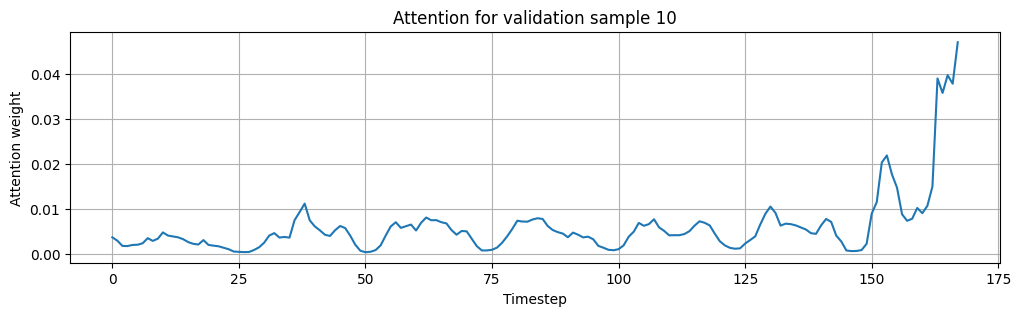

In [132]:
def get_attention_on_validation(model, X_dev_np, batch_size=64):
    """
    Run model on validation set and extract attention weights.

    Returns:
        preds_np: (N, output_dim)
        attn_np:  (N, seq_len)
    """
    model.eval()
    preds = []
    atts = []

    with torch.no_grad():
        for i in range(0, len(X_dev_np), batch_size):
            xb = torch.from_numpy(X_dev_np[i:i+batch_size]).float().to(device)

            # Your model returns (out, attention)
            out, att = model(xb, return_attention=True)

            preds.append(out.cpu().numpy())
            atts.append(att.cpu().numpy())  # shape (B, L)

    preds_np = np.concatenate(preds, axis=0)
    atts_np = np.concatenate(atts, axis=0)

    return preds_np, atts_np

def plot_single_attention(attn, sample_idx=0):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,3))
    plt.plot(attn[sample_idx])
    plt.title(f"Attention for validation sample {sample_idx}")
    plt.xlabel("Timestep")
    plt.ylabel("Attention weight")
    plt.grid(True)
    plt.show()
preds_val, attn_val = get_attention_on_validation(model, X_dev)
print(preds_val.shape)   # (N, output_dim)
print(attn_val.shape)    # (N, seq_len)

plot_single_attention(attn_val, sample_idx=10)





In [133]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, X_test, y_test_FR, y_test_FR_1d, y_test_FR_7d, std_FR=std_FR, mean_FR=mean_FR, device=device)


Evaluating on test set:
MAE: 24.823483, MAEm: 0.592916, rMAE (1 day): 1.154337, rMAE (7 days): 0.772475


Evaluating on training set:
MAE: 20.697836, MAEm: 0.240540, rMAE (1 day): 0.892613, rMAE (7 days): 0.625875


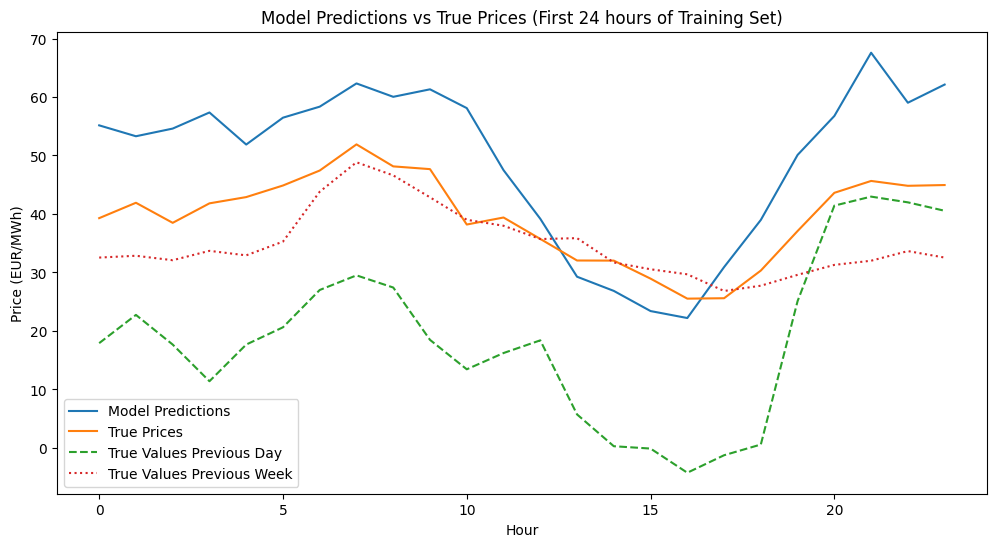

In [135]:
print("Evaluating on training set:")
eval_res_train = evaluate_model(model, X_train, y_train_FR, y_train_FR_1d, y_train_FR_7d, std_FR=std_FR, mean_FR=mean_FR, device=device)
#Plot the first 24 hours of the training set
idx=np.random.randint(168, len(y_train_FR)-1)
plt.figure(figsize=(12,6))
plt.plot(eval_res_train['predictions'][idx], label='Model Predictions')
plt.plot(y_train_FR[idx]*std_FR + mean_FR, label='True Prices')
plt.plot(y_train_FR_1d[idx]*std_FR + mean_FR, label='True Values Previous Day', linestyle='--')
plt.plot(y_train_FR_7d[idx]*std_FR + mean_FR, label='True Values Previous Week', linestyle=':')
plt.title('Model Predictions vs True Prices (First 24 hours of Training Set)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()  

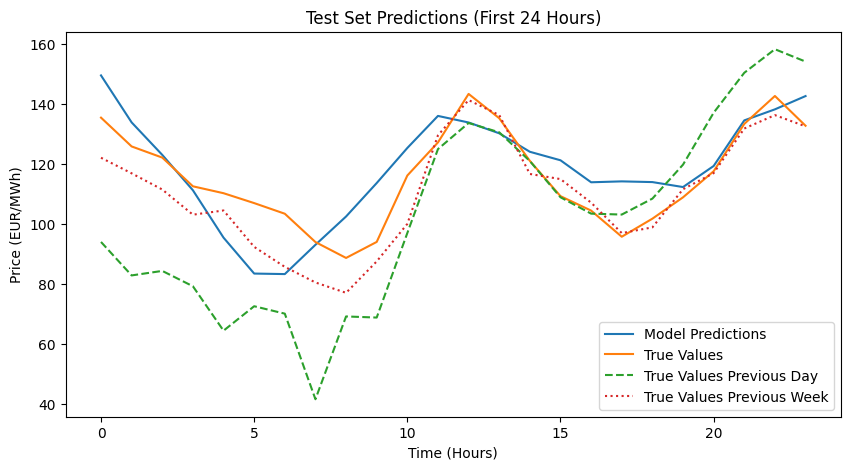

In [136]:
#Plot on the forst 24 hours of the test set
idx=np.random.randint(168, len(y_test_FR)-1)
plt.figure(figsize=(10, 5))
plt.plot(eval_res_test['predictions'][idx], label='Model Predictions')
plt.plot(y_test_FR[idx]*std_FR + mean_FR, label='True Values')
plt.plot(y_test_FR_1d[idx]*std_FR + mean_FR, label='True Values Previous Day', linestyle='--')
plt.plot(y_test_FR_7d[idx]*std_FR + mean_FR, label='True Values Previous Week', linestyle=':')
plt.title('Test Set Predictions (First 24 Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.show()

In [ ]:
#Hyperparameter search
dropout = np.linspace(0.0, 0.5, 5)
lr = np.logspace(-5, -3, 5)
results = {}

for d in dropout:
    for learning_rate in lr:
        print(f"Training with dropout {d} and learning rate {learning_rate}")
        model, train_hist, val_hist = run_full_train(
            X_train, y_train_FR, X_dev, y_dev_FR,
            dropout = d,
            use_batchnorm = False,
            leaky_alpha = 0.0,
            learning_rate = learning_rate,
            weight_decay = 0.0,
            l1_lambda = 0.0,
            batch_size = 128,
            train_amt = len(X_train_FR),
            epochs = 20,
            verbose_freq = 10
        )

        print("Evaluating on dev set:")
        eval_res = evaluate_model(
            model, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, 
            std_FR, mean_FR, device=device
        )
        print("\n")

        # store clean results
        results[(d, learning_rate)] = {
            "MAE": eval_res["MAE"],
            "MAEm": eval_res["MAEm"],
            "rMAE1": eval_res["rMAE (1 day)"],
            "rMAE7": eval_res["rMAE (7 days)"],
        }

# --- find best ---
min_mae = min(v["MAE"] for v in results.values())
min_maem = min(v["MAEm"] for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae = [k for k,v in results.items() if v["MAE"] == min_mae]
best_configs_maem = [k for k,v in results.items() if v["MAEm"] == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print(f"Best configurations for minimum MAE ({min_mae}): {best_configs_mae}")
print(f"Best configurations for minimum MAEm ({min_maem}): {best_configs_maem}")
print(f"Best configurations for minimum rMAE (1 day) ({min_rmae1}): {best_configs_rmae1}")
print(f"Best configurations for minimum rMAE (7 days) ({min_rmae7}): {best_configs_rmae7}")

Training with dropout 0.0 and learning rate 9.999999999999999e-06
Model:
MultiScaleResidualCNN(
  (branch1_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch1_block1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (act): ReLU()
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (branch1_block2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (act): ReLU()
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (branch2_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch2_d1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(10,), dilation=(5,))
    (act): ReLU()
    (conv2): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(10,), dilation=(5,))
  )
  (branch2_d2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(14,), dilation=(7,))

KeyboardInterrupt: 

In [ ]:
results


In [ ]:
# ...existing code...
# This cell: build short labels, fill matrices, find minima and plot grid with metric-text colored per-minimum
# collect unique architectures and lrs (same ordering as rMAE plot)
archs = sorted({k[0] for k in results.keys()})   # dropout values
lrs   = sorted({k[1] for k in results.keys()})   # learning rates


# metrics to show in each grid cell
metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]


# prepare matrices for each metric and multiline text for annotations
metrics_mats = {mk: np.full((len(archs), len(lrs)), np.nan, dtype=float) for mk in metric_keys}
cell_text = np.full((len(archs), len(lrs)), "", dtype=object)

for (arch, lr) in results.keys():
    v = results[(arch, lr)]
    if isinstance(v, dict) and "eval" in v and isinstance(v["eval"], dict):
        ev = v["eval"]
    elif isinstance(v, dict) and any(k in v for k in metric_keys):
        ev = v
    else:
        ev = None

    i = archs.index(arch)   # arch is already a float
    j = lrs.index(lr)       # lr is also a float

    if ev is None:
        cell_text[i, j] = "no eval"
        continue

    # use short, unambiguous labels so rMAE (1 day) / (7 days) are distinct in the cell text
    short_labels = {
        "MAE": "MAE",
        "MAEm": "MAEm",
        "rMAE1": "rMAE1",
        "rMAE7": "rMAE7",
    }

    parts = []
    for mk in metric_keys:
        val = ev.get(mk, np.nan)
        try:
            valf = float(val)
        except Exception:
            valf = np.nan
        metrics_mats[mk][i, j] = valf
        lab = short_labels.get(mk, mk.split()[0])
        parts.append(f"{lab}:{valf:.3f}" if not np.isnan(valf) else f"{lab}:nan")
    cell_text[i, j] = "\n".join(parts)

# --- find minimum positions for each metric (ignore NaNs) ---
min_positions = {}
for mk in metric_keys:
    mat = metrics_mats[mk]
    if np.all(np.isnan(mat)):
        min_positions[mk] = []
    else:
        min_val = np.nanmin(mat)
        # positions as (row, col) tuples
        pos = list(zip(*np.where(np.isclose(mat, min_val, atol=1e-12))))
        min_positions[mk] = pos

# --- Plot grid WITHOUT heatmap, annotate every cell with 4 metrics and highlight minima ---
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(16, 8 + 0.6 * len(archs)))
ax.set_xlim(-0.5, len(lrs) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)  # origin at top to match previous layout
# set_xticks / set_yticks do not accept fontsize; set font size via set_xticklabels / set_yticklabels
ax.set_xticks(range(len(lrs)))
ax.set_xticklabels([f"{lr:.0e}" for lr in lrs], fontsize=16, rotation=45)
ax.set_yticks(range(len(archs)))
ax.set_yticklabels([str(a) for a in archs], fontsize=16)
ax.set_xlabel("learning rate", fontsize=16)
ax.set_ylabel("dropout", fontsize=16)

# draw light grid lines
for x in range(len(lrs) + 1):
    ax.axvline(x - 0.5, color='lightgray', linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color='lightgray', linewidth=0.8)

# colors for each metric's minima (kept distinct)
colors = ['red', 'blue', 'green', 'purple']
metric_colors = {mk: colors[idx % len(colors)] for idx, mk in enumerate(metric_keys)}
legend_patches = [patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys]

# annotate every cell with the 4 metrics as separate text items, color the line if it's a metric minimum
# vertical offsets inside a cell (from top to bottom rows use negative->positive relative to center)
y_offsets = [-0.35, -0.12, 0.12, 0.35]

for i in range(len(archs)):
    for j in range(len(lrs)):
        ev_lines = cell_text[i, j].split("\n") if (cell_text[i, j] and isinstance(cell_text[i, j], str)) else []
        if not ev_lines:
            ax.text(j, i, "no eval", ha='center', va='center', fontsize=7, color='gray')
            continue

        # for each metric place a separate text entry with its own color (default black)
        for k, mk in enumerate(metric_keys):
            line = ev_lines[k] if k < len(ev_lines) else ""
            if not line:
                continue
            # default color
            txt_color = 'black'
            # if this (i,j) is one of the minima positions for this metric, color the metric text
            if (i, j) in min_positions.get(mk, []):
                txt_color = metric_colors[mk]
            ax.text(j, i + y_offsets[k], line, ha='center', va='center', fontsize=16, color=txt_color)

# place legend outside plot to the right
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, borderaxespad=0.1)

plt.tight_layout()
plt.savefig("metrics_grid_minima_text_colored.png", bbox_inches='tight')
plt.show()
# ...existing code...

In [ ]:
def objective(trial):
    # --- Hyperparameters to tune ---
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-7, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs = 20  # you can reduce for faster search

    # --- Train model ---
    MODEL, train_hist, val_hist = run_full_train(
        X_train_np=X_train, y_train_np=y_train_FR,
        X_dev_np=X_dev, y_dev_np=y_dev_FR,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        train_amt=len(X_train),
        epochs=epochs,
        verbose_freq=None
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(MODEL, X_dev, y_dev_FR, y_dev_FR_1d, y_dev_FR_7d, std_FR, mean_FR)
    mae=metrics["MAE"]
    maem=metrics["MAEm"]
    rmae_1d=metrics["rMAE (1 day)"]  # smaller = better
    rmae_7d=metrics["rMAE (7 days)"]  # smaller = better

    return mae,maem, rmae_1d, rmae_7d
# --- Run the study ---
study = optuna.create_study(directions=["minimize","minimize","minimize","minimize"])    
study_name="FR_LMP_MLP"
study.optimize(objective, n_trials=50, timeout=None)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.")

for t in best_trials:
    print(f"Values: {t.values}")
    print(f"Params: {t.params}")



[I 2025-11-16 01:18:08,356] A new study created in memory with name: no-name-438b9024-a582-4c57-8c78-23ade221cbde
/tmp/ipykernel_9397/2004977854.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-2)
/tmp/ipykernel_9397/2004977854.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_9397/2004977854.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  l1_lambda = tria

Model:
MultiScaleResidualCNN(
  (branch1_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch1_block1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (act): LeakyReLU(negative_slope=0.18367077772835702)
    (drop1): Dropout(p=0.2493478405504908, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (branch1_block2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (act): LeakyReLU(negative_slope=0.18367077772835702)
    (drop1): Dropout(p=0.2493478405504908, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (branch2_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch2_d1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(10,), dilation=(5,))
    (act): LeakyReLU(negative_slope=0.18367077772835702)
    (drop1): Dropout(p=0.2493478405504908, inplace=

[I 2025-11-16 01:20:14,610] Trial 0 finished with values: [26.556005477905273, 0.8040253520011902, 1.2957537174224854, 0.962310791015625] and parameters: {'dropout': 0.2493478405504908, 'use_batchnorm': False, 'leaky_alpha': 0.18367077772835702, 'learning_rate': 0.0007719922989944831, 'weight_decay': 0.00028671254862237545, 'l1_lambda': 1.5556997062524794e-07, 'batch_size': 128}.


MAE: 26.556005, MAEm: 0.804025, rMAE (1 day): 1.295754, rMAE (7 days): 0.962311
Model:
MultiScaleResidualCNN(
  (branch1_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch1_block1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.19177364257646715)
    (drop1): Dropout(p=0.4399001706667415, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
  )
  (branch1_block2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.19177364257646715)
    (drop1): Dropout(p=0.4399001706667415, inplace=False)
    (conv2): Conv

[I 2025-11-16 01:23:39,280] Trial 1 finished with values: [38.142757415771484, 1.1548327207565308, 1.8618837594985962, 1.387753963470459] and parameters: {'dropout': 0.4399001706667415, 'use_batchnorm': True, 'leaky_alpha': 0.19177364257646715, 'learning_rate': 0.00012847530126161138, 'weight_decay': 1.7021679050842973e-06, 'l1_lambda': 2.078832786089969e-07, 'batch_size': 64}.


...

MAE: 23.265619, MAEm: 0.704404, rMAE (1 day): 1.136270, rMAE (7 days): 0.843736
Model:
MultiScaleResidualCNN(
  (branch1_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch1_block1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.11090617684034235)
    (drop1): Dropout(p=0.4527882066333172, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn2): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
  )
  (branch1_block2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (bn1): BatchNorm1d(32, eps=0.001, momentum=0.99, affine=True, track_running_stats=True)
    (act): LeakyReLU(negative_slope=0.11090617684034235)
    (drop1): Dropout(p=0.4527882066333172, inplace=False)
    (conv2): Conv

[I 2025-11-16 03:28:50,234] Trial 48 finished with values: [25.465330123901367, 0.7710034251213074, 1.2426884174346924, 0.9216877818107605] and parameters: {'dropout': 0.4527882066333172, 'use_batchnorm': True, 'leaky_alpha': 0.11090617684034235, 'learning_rate': 1.0482197151446976e-05, 'weight_decay': 3.967696074440239e-05, 'l1_lambda': 1.7228911998121216e-05, 'batch_size': 64}.


MAE: 25.465330, MAEm: 0.771003, rMAE (1 day): 1.242688, rMAE (7 days): 0.921688
Model:
MultiScaleResidualCNN(
  (branch1_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch1_block1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (act): LeakyReLU(negative_slope=0.13083449911878295)
    (drop1): Dropout(p=0.026407633456795865, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (branch1_block2): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (act): LeakyReLU(negative_slope=0.13083449911878295)
    (drop1): Dropout(p=0.026407633456795865, inplace=False)
    (conv2): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  )
  (branch2_in): Conv1d(10, 32, kernel_size=(1,), stride=(1,))
  (branch2_d1): ResidualConv1dBlock(
    (conv1): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(10,), dilation=(5,))
    (act): LeakyReLU(neg

[I 2025-11-16 03:30:59,155] Trial 49 finished with values: [24.829360961914062, 0.7517484426498413, 1.2112013101577759, 0.8973985910415649] and parameters: {'dropout': 0.026407633456795865, 'use_batchnorm': False, 'leaky_alpha': 0.13083449911878295, 'learning_rate': 0.00046566695888002963, 'weight_decay': 9.967325253078386e-05, 'l1_lambda': 2.314176735246591e-05, 'batch_size': 256}.


MAE: 24.829361, MAEm: 0.751748, rMAE (1 day): 1.211201, rMAE (7 days): 0.897399
Found 1 Pareto-optimal trials.
Values: [21.45795249938965, 0.6496737003326416, 1.0461153984069824, 0.7738447189331055]
Params: {'dropout': 0.06074082016650889, 'use_batchnorm': True, 'leaky_alpha': 0.19654991821820475, 'learning_rate': 7.07160566302983e-05, 'weight_decay': 0.00020520256697712387, 'l1_lambda': 1.0068678331485069e-05, 'batch_size': 64}
